<a href="https://colab.research.google.com/github/danangcorp/streamlit-prediksihargatiketpesawat/blob/main/prediksi_harga_tiket_pesawat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#STEP 1 — Import Library

In [7]:
pip install xgboost

In [9]:
# ── Data Manipulation ──────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ──────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ───────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# ── Evaluation ─────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Setting Tampilan ───────────────────────────────
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


#STEP 2 — Load & Cek Dataset

In [10]:
# Load Dataset
df = pd.read_csv('airline_ticket_prices_dataset.csv')

# Cek 5 baris pertama
print("=== 5 Baris Pertama ===")
print(df.head())

# Cek info dataset
print("\n=== Info Dataset ===")
print(df.info())

# Cek statistik deskriptif
print("\n=== Statistik Deskriptif ===")
print(df.describe())

# Cek missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Cek duplikat
print("\n=== Jumlah Duplikat ===")
print(df.duplicated().sum())

=== 5 Baris Pertama ===
   Ticket_ID          Airline    Origin Destination  Distance_km     Class  \
0          1           Saudia    Mumbai       Paris         2643   Economy   
1          2           Etihad  Istanbul      Jeddah         8266  Business   
2          3  British Airways     Dubai      Riyadh         2698     First   
3          4         Emirates    London    Istanbul         7956     First   
4          5    Qatar Airways      Doha       Dubai         1308  Business   

   Days_Before_Departure  Price_USD  
0                     28     555.30  
1                     98    2070.27  
2                     21    1883.11  
3                     24    5349.65  
4                     60     516.19  

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              250 non-null    int64

 #STEP 3 — Visualisasi EDA

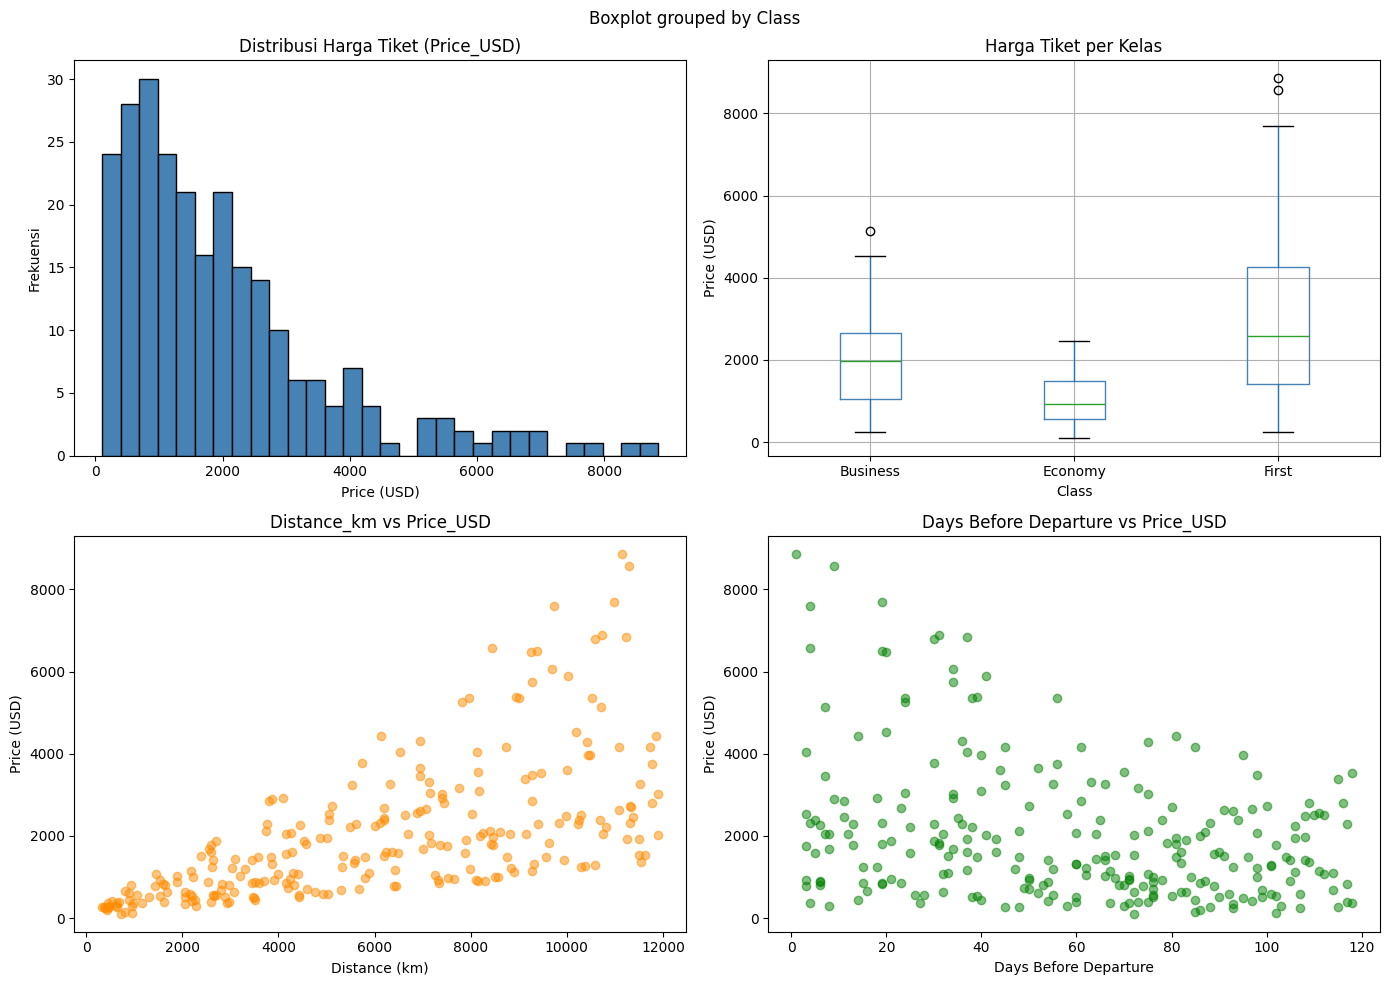

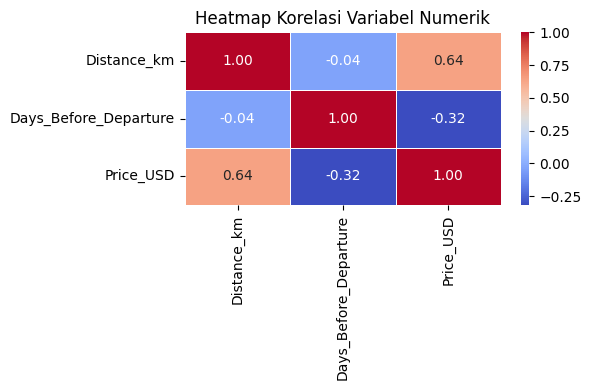

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA - Airline Ticket Prices', fontsize=16, fontweight='bold')

# 1. Distribusi Price_USD
axes[0, 0].hist(df['Price_USD'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribusi Harga Tiket (Price_USD)')
axes[0, 0].set_xlabel('Price (USD)')
axes[0, 0].set_ylabel('Frekuensi')

# 2. Box Plot Price per Class
df.boxplot(column='Price_USD', by='Class', ax=axes[0, 1],
           boxprops=dict(color='steelblue'))
axes[0, 1].set_title('Harga Tiket per Kelas')
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Price (USD)')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

# 3. Scatter: Distance_km vs Price_USD
axes[1, 0].scatter(df['Distance_km'], df['Price_USD'],
                   alpha=0.5, color='darkorange')
axes[1, 0].set_title('Distance_km vs Price_USD')
axes[1, 0].set_xlabel('Distance (km)')
axes[1, 0].set_ylabel('Price (USD)')

# 4. Scatter: Days_Before_Departure vs Price_USD
axes[1, 1].scatter(df['Days_Before_Departure'], df['Price_USD'],
                   alpha=0.5, color='green')
axes[1, 1].set_title('Days Before Departure vs Price_USD')
axes[1, 1].set_xlabel('Days Before Departure')
axes[1, 1].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

# 5. Heatmap Korelasi
plt.figure(figsize=(6, 4))
corr = df[['Distance_km', 'Days_Before_Departure', 'Price_USD']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

# STEP 4 — Preprocessing

In [12]:
# Copy dataset agar data asli tidak berubah
df_clean = df.copy()

# 1. Drop kolom Ticket_ID
df_clean = df_clean.drop(columns=['Ticket_ID'])

# 2. Label Encoding untuk Class (ordinal)
le = LabelEncoder()
df_clean['Class'] = le.fit_transform(df_clean['Class'])
print("=== Mapping Class ===")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

# 3. One-Hot Encoding untuk Airline, Origin, Destination
df_clean = pd.get_dummies(df_clean,
                           columns=['Airline', 'Origin', 'Destination'],
                           drop_first=True)

print(f"\n=== Shape setelah Encoding ===")
print(f"Sebelum : (250, 8)")
print(f"Sesudah : {df_clean.shape}")

# 4. Cek hasil
print("\n=== 3 Baris Pertama Setelah Preprocessing ===")
print(df_clean.head(3))

=== Mapping Class ===
  Business → 0
  Economy → 1
  First → 2

=== Shape setelah Encoding ===
Sebelum : (250, 8)
Sesudah : (250, 29)

=== 3 Baris Pertama Setelah Preprocessing ===
   Distance_km  Class  Days_Before_Departure  Price_USD  Airline_Emirates  \
0         2643      1                     28     555.30             False   
1         8266      0                     98    2070.27             False   
2         2698      2                     21    1883.11             False   

   Airline_Etihad  Airline_Flynas  Airline_Lufthansa  Airline_Qatar Airways  \
0           False           False              False                  False   
1            True           False              False                  False   
2           False           False              False                  False   

   Airline_Saudia  Airline_Turkish Airlines  Origin_Doha  Origin_Dubai  \
0            True                     False        False         False   
1           False                     False  

#STEP 5 — Split Data & Training Model

In [13]:
# 1. Pisahkan Fitur (X) dan Target (y)
X = df_clean.drop(columns=['Price_USD'])
y = df_clean['Price_USD']

# 2. Split Data → 70% Train | 15% Val | 15% Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print("=== Pembagian Dataset ===")
print(f"Training   : {X_train.shape[0]} record")
print(f"Validation : {X_val.shape[0]} record")
print(f"Testing    : {X_test.shape[0]} record")

# 3. Training Model Random Forest
print("\n=== Training Random Forest ===")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Random Forest selesai ditraining!")

# 4. Training Model XGBoost
print("\n=== Training XGBoost ===")
xgb_model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
print("✅ XGBoost selesai ditraining!")

=== Pembagian Dataset ===
Training   : 175 record
Validation : 37 record
Testing    : 38 record

=== Training Random Forest ===
✅ Random Forest selesai ditraining!

=== Training XGBoost ===
✅ XGBoost selesai ditraining!


#STEP 6 — Evaluasi & Perbandingan Model

In [14]:
# Fungsi Evaluasi
def evaluasi_model(nama, model, X, y):
    y_pred = model.predict(X)
    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y_pred)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100
    print(f"\n=== {nama} ===")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")
    print(f"MAPE : {mape:.2f}%")
    return {'Model': nama, 'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}

# Evaluasi pada Data Testing
print("========== EVALUASI DATA TESTING ==========")
hasil_rf  = evaluasi_model("Random Forest", rf_model, X_test, y_test)
hasil_xgb = evaluasi_model("XGBoost",       xgb_model, X_test, y_test)

# Tabel Perbandingan
print("\n========== TABEL PERBANDINGAN ==========")
df_hasil = pd.DataFrame([hasil_rf, hasil_xgb])
df_hasil = df_hasil.set_index('Model')
print(df_hasil.round(2))

========== EVALUASI DATA TESTING ==========

=== Random Forest ===
MAE  : 203.23
RMSE : 286.53
R²   : 0.9594
MAPE : 14.05%

=== XGBoost ===
MAE  : 253.40
RMSE : 355.72
R²   : 0.9374
MAPE : 13.49%

========== TABEL PERBANDINGAN ==========
                  MAE    RMSE    R²   MAPE
Model                                     
Random Forest  203.23  286.53  0.96  14.05
XGBoost        253.40  355.72  0.94  13.49


#STEP 7 — Visualisasi Evaluasi

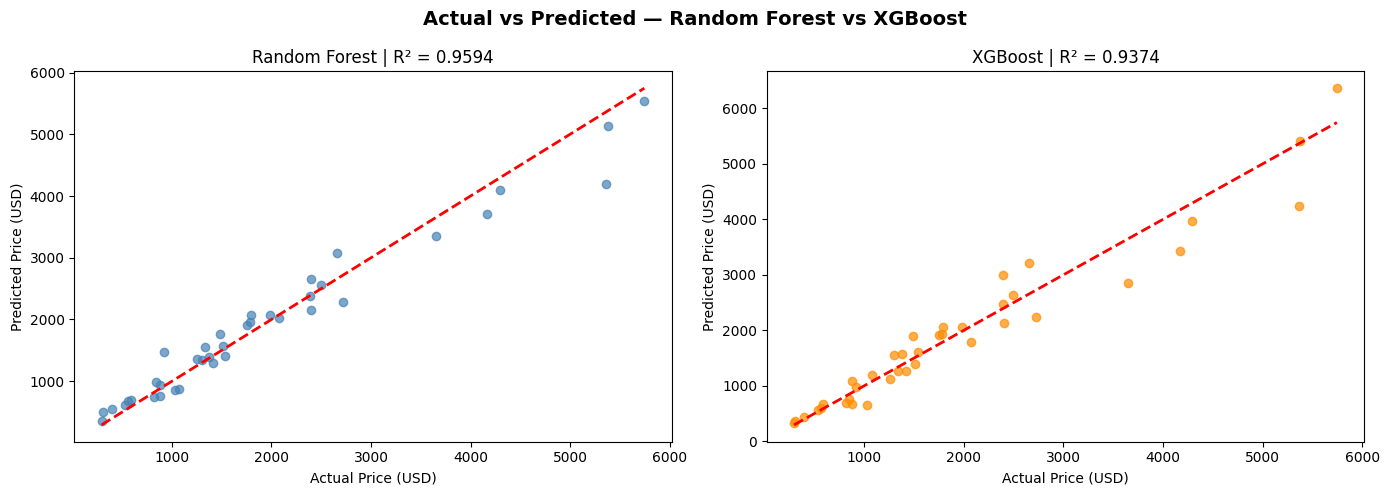

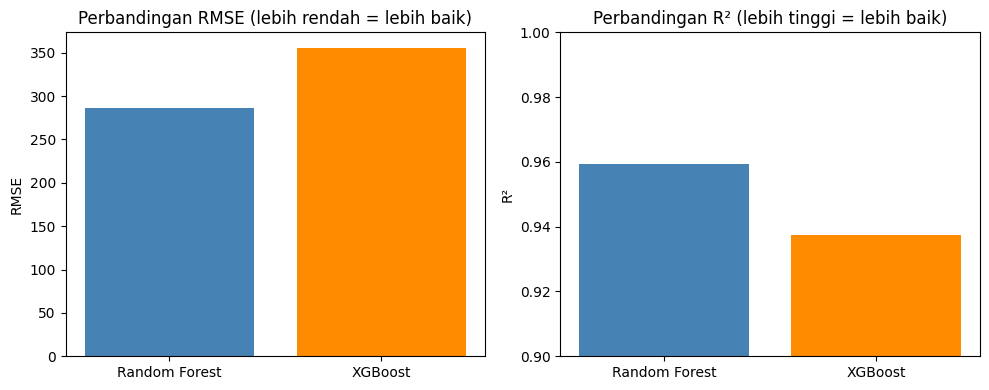

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Actual vs Predicted — Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')

y_pred_rf  = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Plot Random Forest
axes[0].scatter(y_test, y_pred_rf, alpha=0.7, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Random Forest | R² = 0.9594')
axes[0].set_xlabel('Actual Price (USD)')
axes[0].set_ylabel('Predicted Price (USD)')

# Plot XGBoost
axes[1].scatter(y_test, y_pred_xgb, alpha=0.7, color='darkorange')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title(f'XGBoost | R² = 0.9374')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')

plt.tight_layout()
plt.show()

# Bar Chart Perbandingan Metrik
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# RMSE
axes[0].bar(['Random Forest', 'XGBoost'], [286.53, 355.72],
            color=['steelblue', 'darkorange'])
axes[0].set_title('Perbandingan RMSE (lebih rendah = lebih baik)')
axes[0].set_ylabel('RMSE')

# R²
axes[1].bar(['Random Forest', 'XGBoost'], [0.9594, 0.9374],
            color=['steelblue', 'darkorange'])
axes[1].set_title('Perbandingan R² (lebih tinggi = lebih baik)')
axes[1].set_ylabel('R²')
axes[1].set_ylim([0.90, 1.0])

plt.tight_layout()
plt.show()

#STEP 8 — Feature Importance

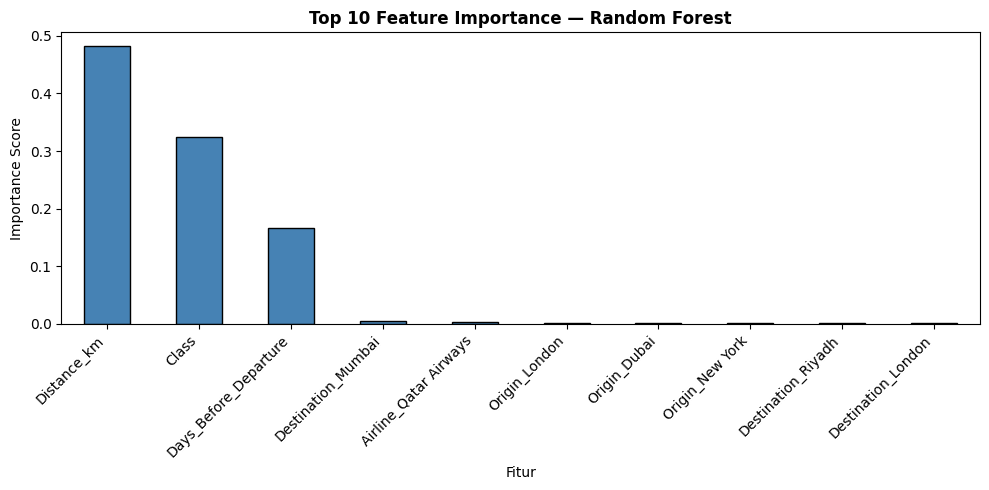

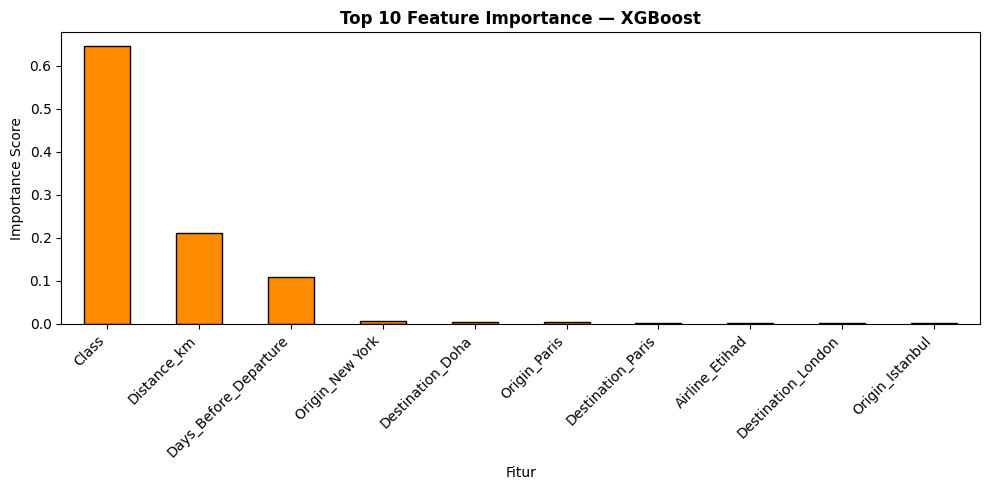

=== Top 10 Feature Importance — Random Forest ===
Distance_km              0.4818
Class                    0.3237
Days_Before_Departure    0.1673
Destination_Mumbai       0.0043
Airline_Qatar Airways    0.0040
Origin_London            0.0017
Origin_Dubai             0.0015
Origin_New York          0.0014
Destination_Riyadh       0.0014
Destination_London       0.0012

=== Top 10 Feature Importance — XGBoost ===
Class                    0.6455
Distance_km              0.2113
Days_Before_Departure    0.1099
Origin_New York          0.0058
Destination_Doha         0.0045
Origin_Paris             0.0035
Destination_Paris        0.0032
Airline_Etihad           0.0031
Destination_London       0.0026
Origin_Istanbul          0.0021


In [16]:
# 1. Feature Importance — Random Forest
feat_imp_rf = pd.Series(rf_model.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)

# Ambil Top 10
top10_rf = feat_imp_rf.head(10)

plt.figure(figsize=(10, 5))
top10_rf.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Fitur')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Feature Importance — XGBoost
feat_imp_xgb = pd.Series(xgb_model.feature_importances_,
                          index=X_train.columns).sort_values(ascending=False)

# Ambil Top 10
top10_xgb = feat_imp_xgb.head(10)

plt.figure(figsize=(10, 5))
top10_xgb.plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Top 10 Feature Importance — XGBoost', fontweight='bold')
plt.xlabel('Fitur')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Tampilkan dalam tabel
print("=== Top 10 Feature Importance — Random Forest ===")
print(top10_rf.round(4).to_string())

print("\n=== Top 10 Feature Importance — XGBoost ===")
print(top10_xgb.round(4).to_string())

#STEP 9 — Kesimpulan Final

In [17]:
print("=" * 55)
print("        KESIMPULAN AKHIR PENELITIAN")
print("=" * 55)

print("""
📌 DATASET
   Total data     : 250 record
   Fitur dipakai  : 28 fitur (setelah encoding)
   Target         : Price_USD
""")

print("📌 PERBANDINGAN MODEL")
print(f"{'Metrik':<10} {'Random Forest':>15} {'XGBoost':>12} {'Terbaik':>10}")
print("-" * 50)
print(f"{'MAE':<10} {'203.23':>15} {'253.40':>12} {'RF ✅':>10}")
print(f"{'RMSE':<10} {'286.53':>15} {'355.72':>12} {'RF ✅':>10}")
print(f"{'R²':<10} {'0.9594':>15} {'0.9374':>12} {'RF ✅':>10}")
print(f"{'MAPE':<10} {'14.05%':>15} {'13.49%':>12} {'XGB ✅':>10}")

print("""
📌 MODEL TERPILIH → RANDOM FOREST
   ✅ R²   = 0.9594 (target ≥ 0.85 → TERCAPAI)
   ✅ MAPE = 14.05% (target ≤ 15% → TERCAPAI)
   ✅ Unggul di 3 dari 4 metrik evaluasi

📌 FAKTOR UTAMA PENENTU HARGA TIKET
   1. Distance_km          → Jarak penerbangan
   2. Class                → Kelas penerbangan
   3. Days_Before_Departure→ Hari sebelum terbang

📌 REKOMENDASI
   Gunakan Random Forest sebagai model final
   untuk sistem prediksi harga tiket pesawat.
""")
print("=" * 55)

        KESIMPULAN AKHIR PENELITIAN

📌 DATASET
   Total data     : 250 record
   Fitur dipakai  : 28 fitur (setelah encoding)
   Target         : Price_USD

📌 PERBANDINGAN MODEL
Metrik       Random Forest      XGBoost    Terbaik
--------------------------------------------------
MAE                 203.23       253.40       RF ✅
RMSE                286.53       355.72       RF ✅
R²                  0.9594       0.9374       RF ✅
MAPE                14.05%       13.49%      XGB ✅

📌 MODEL TERPILIH → RANDOM FOREST
   ✅ R²   = 0.9594 (target ≥ 0.85 → TERCAPAI)
   ✅ MAPE = 14.05% (target ≤ 15% → TERCAPAI)
   ✅ Unggul di 3 dari 4 metrik evaluasi

📌 FAKTOR UTAMA PENENTU HARGA TIKET
   1. Distance_km          → Jarak penerbangan
   2. Class                → Kelas penerbangan  
   3. Days_Before_Departure→ Hari sebelum terbang

📌 REKOMENDASI
   Gunakan Random Forest sebagai model final
   untuk sistem prediksi harga tiket pesawat.



In [20]:
# Kamu perlu cek ini di notebook:

# Evaluasi di data TRAINING
y_pred_train_rf = rf_model.predict(X_train)
r2_train = r2_score(y_train, y_pred_train_rf)

# Evaluasi di data TESTING
r2_test = 0.9594

print(f"R² Training : {r2_train:.4f}")
print(f"R² Testing  : {r2_test:.4f}")
print(f"Selisih     : {r2_train - r2_test:.4f}")

# Aturan:
# Selisih < 0.05 → Tidak overfitting ✅
# Selisih > 0.10 → Overfitting ⚠️

R² Training : 0.9937
R² Testing  : 0.9594
Selisih     : 0.0343
